In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.formula.api as smf
import warnings
import os
import pandas as pd
from matplotlib import pyplot as plt
warnings.filterwarnings('ignore')

In [48]:
# 파일 경로 확인.
proj_path = os.path.dirname(os.path.dirname(Path.cwd()))
LDT_file_path = os.path.join(proj_path, 'src','LDT-data')
SUBTLEX_target_path = os.path.join(proj_path, 'src','SUBTLEX_stimuli(60).xlsx')
KE_target_path = os.path.join(proj_path, 'src','KE_stimuli(60).xlsx')

In [49]:
# target word list load
cols = ['Word', 'KE_rank', 'SUBTLEX_rank', 'Zipf_KE', 'Zipf_SUBTLEX']
SUBTLEX_target_df = pd.read_excel(SUBTLEX_target_path)[cols]
KE_target_df = pd.read_excel(KE_target_path)[cols]


In [50]:
SUBTLEX_target_df.rename(columns={'Word': 'Stimuli'}, inplace=True)
KE_target_df.rename(columns={'Word': 'Stimuli'}, inplace=True)


In [51]:
csv_list = [file for file in os.listdir(LDT_file_path) if file.endswith('.csv')]
csv_list.__len__()

51

In [52]:
data_df = pd.read_csv(os.path.join(LDT_file_path, csv_list[0]))
data_df.head()

,Task,TrialType,Stimuli,CorrectResponse,StimulusType,thisN,thisTrialN,thisRepN,Trialnumb,LDT_key_resp.keys,...,end.started,end.stopped,Participant,date,expName,expVersion,psychopyVersion,frameRate,expStart,Unnamed: 54
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,MB21,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,MB21,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,NaN
2,LDT,Practice,baseball,l,word,0.0,0.0,0.0,NaN,NaN,...,NaN,NaN,MB21,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,NaN
3,LDT,Practice,cucumber,l,word,1.0,1.0,0.0,NaN,NaN,...,NaN,NaN,MB21,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,NaN
4,LDT,Practice,cluerk,a,nonword,2.0,2.0,0.0,NaN,NaN,...,NaN,NaN,MB21,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,NaN


In [53]:
SUBTLEX_cumulative_df = None
KE_cumulative_df = None
for file in csv_list:
    
    data_df = pd.read_csv(os.path.join(LDT_file_path, file))
    data_df.drop(columns=['Unnamed: 54'], inplace=True)
    
    mask_target = data_df['TrialType'] == 'Target'
    SUBTLEX_mask = data_df['Stimuli'].isin(SUBTLEX_target_df['Stimuli'])
    KE_mask = data_df['Stimuli'].isin(KE_target_df['Stimuli'])
    SUBTLEX_df = data_df[mask_target & SUBTLEX_mask]
    KE_df = data_df[mask_target & KE_mask]
    
    if SUBTLEX_cumulative_df is None:
        SUBTLEX_cumulative_df = pd.merge(SUBTLEX_df, SUBTLEX_target_df, on='Stimuli', how='left')
        KE_cumulative_df = pd.merge(KE_df, KE_target_df, on='Stimuli', how='left')

    else:
        SUBTLEX_cumulative_df = pd.concat([SUBTLEX_cumulative_df, pd.merge(SUBTLEX_df, SUBTLEX_target_df, on='Stimuli', how='left')]).reset_index(drop=True)
        KE_cumulative_df = pd.concat([KE_cumulative_df, pd.merge(KE_df, KE_target_df, on='Stimuli', how='left')]).reset_index(drop=True)

# 각각 나눠서 ANOVA

In [54]:
SUBTLEX_cumulative_df

,Task,TrialType,Stimuli,CorrectResponse,StimulusType,thisN,thisTrialN,thisRepN,Trialnumb,LDT_key_resp.keys,...,date,expName,expVersion,psychopyVersion,frameRate,expStart,KE_rank,SUBTLEX_rank,Zipf_KE,Zipf_SUBTLEX
0,LDT,Target,area,l,word,7.0,7.0,0.0,49.0,l,...,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,69.153226,29.943125,5.307500,4.874079
1,LDT,Target,rear,l,word,12.0,12.0,0.0,110.0,l,...,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,98.991935,78.889261,3.962267,4.094524
2,LDT,Target,trick,l,word,15.0,15.0,0.0,75.0,l,...,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,96.774194,41.284711,4.372441,4.674134
3,LDT,Target,raise,l,word,24.0,24.0,0.0,73.0,l,...,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,90.927419,37.336902,4.789267,4.741461
4,LDT,Target,mass,l,word,26.0,26.0,0.0,102.0,l,...,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,89.314516,71.194379,4.857531,4.236650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3055,LDT,Target,slim,l,word,210.0,210.0,0.0,111.0,l,...,2025-10-17_13h12.51.381,online_LDT&KRT,NaN,2025.1.1,121.029770,2025-10-17 13h12.57.532544 +0900,99.596774,79.859485,3.719229,4.074170
3056,LDT,Target,boom,l,word,216.0,216.0,0.0,96.0,l,...,2025-10-17_13h12.51.381,online_LDT&KRT,NaN,2025.1.1,121.029770,2025-10-17 13h12.57.532544 +0900,99.395161,64.603546,3.816139,4.338215
3057,LDT,Target,art,l,word,217.0,217.0,0.0,15.0,l,...,2025-10-17_13h12.51.381,online_LDT&KRT,NaN,2025.1.1,121.029770,2025-10-17 13h12.57.532544 +0900,36.088710,31.114085,5.727829,4.849521
3058,LDT,Target,pack,l,word,219.0,219.0,0.0,76.0,l,...,2025-10-17_13h12.51.381,online_LDT&KRT,NaN,2025.1.1,121.029770,2025-10-17 13h12.57.532544 +0900,95.967742,43.593175,4.459591,4.641235


In [55]:
KE_cumulative_df

,Task,TrialType,Stimuli,CorrectResponse,StimulusType,thisN,thisTrialN,thisRepN,Trialnumb,LDT_key_resp.keys,...,date,expName,expVersion,psychopyVersion,frameRate,expStart,KE_rank,SUBTLEX_rank,Zipf_KE,Zipf_SUBTLEX
0,LDT,Target,come,l,word,0.0,0.0,0.0,7.0,l,...,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,27.419355,1.773168,5.873805,6.496436
1,LDT,Target,full,l,word,4.0,4.0,0.0,43.0,l,...,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,62.903226,17.263299,5.386682,5.221875
2,LDT,Target,area,l,word,7.0,7.0,0.0,49.0,l,...,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,69.153226,29.943125,5.307500,4.874079
3,LDT,Target,man,l,word,11.0,11.0,0.0,12.0,l,...,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,31.250000,2.709936,5.818737,6.265545
4,LDT,Target,long,l,word,14.0,14.0,0.0,6.0,l,...,2025-10-22_11h40.47.202,online_LDT&KRT,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,25.806452,5.754433,5.898924,5.828787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3055,LDT,Target,back,l,word,181.0,181.0,0.0,8.0,l,...,2025-10-17_13h12.51.381,online_LDT&KRT,NaN,2025.1.1,121.029770,2025-10-17 13h12.57.532544 +0900,27.822581,2.442288,5.869217,6.302387
3056,LDT,Target,side,l,word,201.0,201.0,0.0,48.0,l,...,2025-10-17_13h12.51.381,online_LDT&KRT,NaN,2025.1.1,121.029770,2025-10-17 13h12.57.532544 +0900,68.145161,15.189026,5.321289,5.302433
3057,LDT,Target,news,l,word,209.0,209.0,0.0,45.0,l,...,2025-10-17_13h12.51.381,online_LDT&KRT,NaN,2025.1.1,121.029770,2025-10-17 13h12.57.532544 +0900,65.927419,17.430579,5.350165,5.216087
3058,LDT,Target,art,l,word,217.0,217.0,0.0,15.0,l,...,2025-10-17_13h12.51.381,online_LDT&KRT,NaN,2025.1.1,121.029770,2025-10-17 13h12.57.532544 +0900,36.088710,31.114085,5.727829,4.849521


In [56]:
KE_cumulative_df.columns

Index(['Task', 'TrialType', 'Stimuli', 'CorrectResponse', 'StimulusType',
       'thisN', 'thisTrialN', 'thisRepN', 'Trialnumb', 'LDT_key_resp.keys',
       'LDT_key_resp.corr', 'LDT_key_resp.rt', 'LDT_key_resp.duration',
       'LDT_prac_trials.thisRepN', 'LDT_prac_trials.thisTrialN',
       'LDT_prac_trials.thisN', 'LDT_prac_trials.thisIndex',
       'LDT_trials.thisRepN', 'LDT_trials.thisTrialN', 'LDT_trials.thisN',
       'LDT_trials.thisIndex', 'thisRow.t', 'notes', 'Intro.started',
       'Intro.stopped', 'LDT_intro.started', 'keyboard_LDT.started',
       'LDT_intro.stopped', 'LDT_prac.started', 'LDT_prac.stopped',
       'LDT_feedback.started', 'LDT_feedback.stopped', 'LDT_instr.started',
       'LDT_instr_key_resp.started', 'LDT_instr.stopped', 'LDT_trial.started',
       'LDT_stim_text.started', 'LDT_key_resp.started', 'LDT_trial.stopped',
       'LDT_trials.LDT_key_resp.keys', 'LDT_trials.LDT_key_resp.corr',
       'LDT_trials.LDT_key_resp.rt', 'LDT_trials.LDT_key_resp.durat

In [70]:
# 통계 분석을 위한 추가 라이브러리 import
from scipy import stats
from scipy.stats import f_oneway, ttest_ind
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.formula.api as smf
import warnings
import os
import pandas as pd
from matplotlib import pyplot as plt
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore')

In [71]:
SUBTLEX_cumulative_df.rename(columns={'LDT_trials.LDT_key_resp.rt': 'rt'}, inplace=True)
SUBTLEX_cumulative_df['log_rt'] = np.log10(SUBTLEX_cumulative_df['rt'])
SUBTLEX_cumulative_df['log_rt']

0      -0.308031
1      -0.168796
2      -0.246965
3      -0.304174
4      -0.370020
          ...   
3055   -0.289531
3056   -0.247660
3057   -0.289190
3058   -0.394718
3059   -0.435303
Name: log_rt, Length: 3060, dtype: float64

In [72]:
SUBTLEX_cumulative_df['Participant'] = SUBTLEX_cumulative_df['Participant'].astype(str)

In [73]:
KE_cumulative_df.rename(columns={'LDT_trials.LDT_key_resp.rt': 'rt'}, inplace=True)
KE_cumulative_df['log_rt'] = np.log10(KE_cumulative_df['rt'])
KE_cumulative_df['log_rt']

0      -0.188421
1      -0.399600
2      -0.308031
3      -0.277381
4      -0.285678
          ...   
3055   -0.239343
3056   -0.365893
3057   -0.288847
3058   -0.289190
3059   -0.397346
Name: log_rt, Length: 3060, dtype: float64

In [74]:
KE_cumulative_df['Participant'] = KE_cumulative_df['Participant'].astype(str)

In [75]:
SUBTLEX_cumulative_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 59 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Task                              3060 non-null   object 
 1   TrialType                         3060 non-null   object 
 2   Stimuli                           3060 non-null   object 
 3   CorrectResponse                   3060 non-null   object 
 4   StimulusType                      3060 non-null   object 
 5   thisN                             3060 non-null   float64
 6   thisTrialN                        3060 non-null   float64
 7   thisRepN                          3060 non-null   float64
 8   Trialnumb                         3060 non-null   float64
 9   LDT_key_resp.keys                 3060 non-null   object 
 10  LDT_key_resp.corr                 3060 non-null   float64
 11  LDT_key_resp.rt                   3060 non-null   float64
 12  LDT_ke

In [76]:
SUBTLEX_cumulative_df['Participant'].unique()

array(['MB21', 'MB25', 'MB31', 'MB22', 'MB01', 'MB03', 'MB40', 'MB34',
       'MB20', '51', 'MB38', 'MB15', 'MB06', 'MB54', 'MB47', 'MB28',
       'MB13', 'MB52', 'MB10', 'MB33', 'MB24', 'MB50', 'MB41', 'MB29',
       'MB11', 'MB35', 'MB12', 'MB32', 'MB08', 'MB48', 'MB42', 'MB27',
       'MB45', 'MB30', 'MB26', 'MB05', 'MB39', 'MB09', 'MB23', 'MB16',
       'MB14', 'MB43', 'MB02', 'MB07', 'MB04', 'MB36', 'MB19', 'MB55',
       'MB37', 'MB17', 'MB18'], dtype=object)

In [77]:
column_mapping = {
    '6' : 'MB06',
    'mb03' : 'MB03',
    'MB004(Juhyeon)' : 'MB04',
    'MA33' : 'MB33',
    '51' : 'MB51',
}
SUBTLEX_cumulative_df['Participant'] = SUBTLEX_cumulative_df['Participant'].replace(column_mapping)
KE_cumulative_df['Participant'] = KE_cumulative_df['Participant'].replace(column_mapping)

In [78]:
SUBTLEX_cumulative_df['Participant'].unique()

array(['MB21', 'MB25', 'MB31', 'MB22', 'MB01', 'MB03', 'MB40', 'MB34',
       'MB20', 'MB51', 'MB38', 'MB15', 'MB06', 'MB54', 'MB47', 'MB28',
       'MB13', 'MB52', 'MB10', 'MB33', 'MB24', 'MB50', 'MB41', 'MB29',
       'MB11', 'MB35', 'MB12', 'MB32', 'MB08', 'MB48', 'MB42', 'MB27',
       'MB45', 'MB30', 'MB26', 'MB05', 'MB39', 'MB09', 'MB23', 'MB16',
       'MB14', 'MB43', 'MB02', 'MB07', 'MB04', 'MB36', 'MB19', 'MB55',
       'MB37', 'MB17', 'MB18'], dtype=object)

In [79]:
KE_cumulative_df['Participant'].unique()

array(['MB21', 'MB25', 'MB31', 'MB22', 'MB01', 'MB03', 'MB40', 'MB34',
       'MB20', 'MB51', 'MB38', 'MB15', 'MB06', 'MB54', 'MB47', 'MB28',
       'MB13', 'MB52', 'MB10', 'MB33', 'MB24', 'MB50', 'MB41', 'MB29',
       'MB11', 'MB35', 'MB12', 'MB32', 'MB08', 'MB48', 'MB42', 'MB27',
       'MB45', 'MB30', 'MB26', 'MB05', 'MB39', 'MB09', 'MB23', 'MB16',
       'MB14', 'MB43', 'MB02', 'MB07', 'MB04', 'MB36', 'MB19', 'MB55',
       'MB37', 'MB17', 'MB18'], dtype=object)

In [117]:
KE_cumulative_df['Participant'].value_counts().shape

(51,)

# Merging LexTALE

In [80]:
lextale_path = os.path.join(proj_path, 'src', 'LexTALE(1119).xlsx')
lextale_df = pd.read_excel(lextale_path)
lextale_df.head()

,참가자 번호,이름,일시,점수,비고
0,MB01,이유승,2025-10-13 10:00:00,48.75,근장
1,MB02,이여규,2025-10-14 11:00:00,66.25,인턴
2,MB03,정유라,2025-10-13 14:00:00,65,근장
3,MB04,박주현,2025-10-13 16:00:00,73.75,나-실험자
4,MB05,유희상,2025-10-17 09:00:00,60,인턴


In [81]:
KE_lex_score = []
for idx, item in KE_cumulative_df.iterrows():
    case_mask = lextale_df['참가자 번호'] == item.get('Participant')
    if case_mask.sum() == 0:
        raise ValueError(f"Participant {item.get('Participant')} not found in LexTALE")
    else:
        KE_lex_score.append(lextale_df[case_mask]['점수'].values[0])

KE_cumulative_df['LexTALE'] = KE_lex_score
KE_cumulative_df.head()


,Task,TrialType,Stimuli,CorrectResponse,StimulusType,thisN,thisTrialN,thisRepN,Trialnumb,LDT_key_resp.keys,...,expVersion,psychopyVersion,frameRate,expStart,KE_rank,SUBTLEX_rank,Zipf_KE,Zipf_SUBTLEX,log_rt,LexTALE
0,LDT,Target,come,l,word,0.0,0.0,0.0,7.0,l,...,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,27.419355,1.773168,5.873805,6.496436,-0.188421,67.5
1,LDT,Target,full,l,word,4.0,4.0,0.0,43.0,l,...,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,62.903226,17.263299,5.386682,5.221875,-0.399600,67.5
2,LDT,Target,area,l,word,7.0,7.0,0.0,49.0,l,...,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,69.153226,29.943125,5.307500,4.874079,-0.308031,67.5
3,LDT,Target,man,l,word,11.0,11.0,0.0,12.0,l,...,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,31.250000,2.709936,5.818737,6.265545,-0.277381,67.5
4,LDT,Target,long,l,word,14.0,14.0,0.0,6.0,l,...,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,25.806452,5.754433,5.898924,5.828787,-0.285678,67.5


In [82]:
SUBTLEX_lex_score = []
for idx, item in SUBTLEX_cumulative_df.iterrows():
    case_mask = lextale_df['참가자 번호'] == item.get('Participant')
    if case_mask.sum() == 0:
        raise ValueError(f"Participant {item.get('Participant')} not found in LexTALE")
    else:
        SUBTLEX_lex_score.append(lextale_df[case_mask]['점수'].values[0])

SUBTLEX_cumulative_df['LexTALE'] = SUBTLEX_lex_score
SUBTLEX_cumulative_df.head()


,Task,TrialType,Stimuli,CorrectResponse,StimulusType,thisN,thisTrialN,thisRepN,Trialnumb,LDT_key_resp.keys,...,expVersion,psychopyVersion,frameRate,expStart,KE_rank,SUBTLEX_rank,Zipf_KE,Zipf_SUBTLEX,log_rt,LexTALE
0,LDT,Target,area,l,word,7.0,7.0,0.0,49.0,l,...,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,69.153226,29.943125,5.307500,4.874079,-0.308031,67.5
1,LDT,Target,rear,l,word,12.0,12.0,0.0,110.0,l,...,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,98.991935,78.889261,3.962267,4.094524,-0.168796,67.5
2,LDT,Target,trick,l,word,15.0,15.0,0.0,75.0,l,...,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,96.774194,41.284711,4.372441,4.674134,-0.246965,67.5
3,LDT,Target,raise,l,word,24.0,24.0,0.0,73.0,l,...,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,90.927419,37.336902,4.789267,4.741461,-0.304174,67.5
4,LDT,Target,mass,l,word,26.0,26.0,0.0,102.0,l,...,NaN,2025.1.1,121.033725,2025-10-22 11h40.54.045990 +0900,89.314516,71.194379,4.857531,4.236650,-0.370020,67.5


# Model Fitting

In [83]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [85]:
def return_r2(model):
    y_pred = model.fittedvalues
    y_true = model.model.endog
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    return r2

In [130]:
import numpy as np

def mixedlm_r2(res):
    """
    res: fitted statsmodels MixedLMResults object
    Returns: dict with 'var_fixed', 'var_random', 'var_resid', 'R2_marginal', 'R2_conditional'
    """
    # 1) fixed effects linear predictor for each observation
    # exog: design matrix for fixed effects
    X = res.model.exog  # (n_obs x k)
    fe = res.fe_params.values.reshape(-1, 1)  # (k x 1)
    linpred = X.dot(fe).flatten()
    var_fixed = np.var(linpred, ddof=0)

    # 2) random effect variances
    # a) group-level random effects (from cov_re)
    var_random = 0.0
    try:
        # cov_re can be a matrix; if random intercept only, cov_re is 1x1
        cov_re = res.cov_re  # numpy array or DataFrame-like
        # sum diagonal elements (variances) of cov_re for random effects per group
        var_random += np.trace(np.atleast_2d(cov_re))
    except Exception:
        # if attribute not present, ignore
        pass

    # b) variance components from vc_formula (if any)
    try:
        # res.vcomp is array of variance components in statsmodels
        vcomp = np.asarray(res.vcomp)  # may be empty
        if vcomp.size > 0:
            var_random += vcomp.sum()
    except Exception:
        pass

    # 3) residual variance (scale)
    var_resid = float(res.scale)  # residual variance estimate

    # 4) total variance
    var_total = var_fixed + var_random + var_resid

    R2_marginal = var_fixed / var_total
    R2_conditional = (var_fixed + var_random) / var_total

    return {
        'var_fixed': var_fixed,
        'var_random': var_random,
        'var_resid': var_resid,
        'var_total': var_total,
        'R2_marginal': R2_marginal,
        'R2_conditional': R2_conditional
    }

In [122]:
from scipy.stats import zscore
SUBTLEX_cumulative_df['Zipf_SUBTLEX_z'] = zscore(SUBTLEX_cumulative_df['Zipf_SUBTLEX'])
SUBTLEX_cumulative_df['Zipf_KE_z'] = zscore(SUBTLEX_cumulative_df['Zipf_KE'])
KE_cumulative_df['Zipf_SUBTLEX_z'] = zscore(KE_cumulative_df['Zipf_SUBTLEX'])
KE_cumulative_df['Zipf_KE_z'] = zscore(KE_cumulative_df['Zipf_KE'])

In [131]:
# LMM
formula = 'log_rt ~ Zipf_SUBTLEX_z' # regression formula
vc_formula = { # variance component formula
    "word": "0 + C(Stimuli)"
    }
re_formula = '~1' # random slope formula
#'~C(vowel_label)' 는 수렴하지 않아서 제외.
model = MixedLM.from_formula(formula,
    data=SUBTLEX_cumulative_df, 
    groups='Participant',
    vc_formula=vc_formula,
    re_formula=re_formula
    ).fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
===========================================================
Model:              MixedLM  Dependent Variable:  log_rt   
No. Observations:   3060     Method:              REML     
No. Groups:         51       Scale:               0.0061   
Min. group size:    60       Log-Likelihood:      2120.0836
Max. group size:    60       Converged:           Yes      
Mean group size:    60.0                                   
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept       -0.194    0.009 -22.760 0.000 -0.211 -0.177
Zipf_SUBTLEX_z  -0.019    0.002  -8.820 0.000 -0.023 -0.015
Participant Var  0.003                                     
word Var         0.008                                     
===========================================================

"""

In [132]:
print(f"R²: {return_r2(model):.4f}")

R²: 0.8486


In [134]:
print("Marginal R2:", mixedlm_r2(model)['R2_marginal'])
print("Conditional R2:", mixedlm_r2(model)['R2_conditional'])

Marginal R2: 0.019935376757649732
Conditional R2: 0.6534407522050677


In [135]:
# LMM
formula = 'log_rt ~ Zipf_KE_z' # regression formula
vc_formula = { # variance component formula
    "word": "0 + C(Stimuli)"
    }
re_formula = '~1' # random slope formula
#'~C(vowel_label)' 는 수렴하지 않아서 제외.
model = MixedLM.from_formula(formula,
    data=KE_cumulative_df, 
    groups='Participant',
    vc_formula=vc_formula,
    re_formula=re_formula
    ).fit()
# groups에 id 
model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
===========================================================
Model:              MixedLM  Dependent Variable:  log_rt   
No. Observations:   3060     Method:              REML     
No. Groups:         51       Scale:               0.0043   
Min. group size:    60       Log-Likelihood:      2668.4760
Max. group size:    60       Converged:           Yes      
Mean group size:    60.0                                   
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept       -0.245    0.007 -34.317 0.000 -0.259 -0.231
Zipf_KE_z       -0.005    0.002  -2.738 0.006 -0.008 -0.001
Participant Var  0.002                                     
word Var         0.005                                     
===========================================================

"""

In [136]:
print(f"R²: {return_r2(model):.4f}")

R²: 0.8458


In [137]:
print("Marginal R2:", mixedlm_r2(model)['R2_marginal'])
print("Conditional R2:", mixedlm_r2(model)['R2_conditional'])

Marginal R2: 0.0019558745625755836
Conditional R2: 0.6471167623256306


<Axes: xlabel='Zipf_SUBTLEX_z', ylabel='log_rt'>

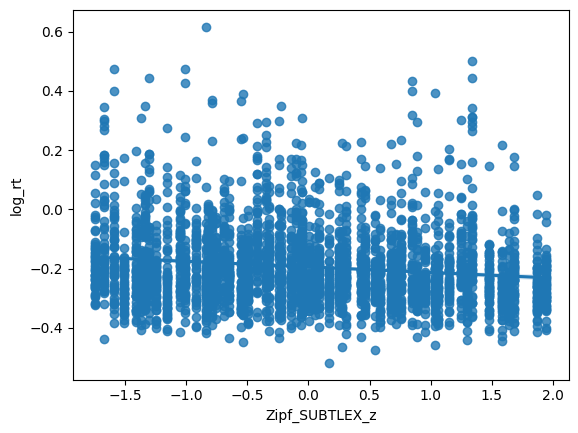

In [127]:
#plt.ylim(-0.6, 1)
sns.regplot(x='Zipf_SUBTLEX_z', y='log_rt', data=SUBTLEX_cumulative_df)

<Axes: xlabel='Zipf_KE_z', ylabel='log_rt'>

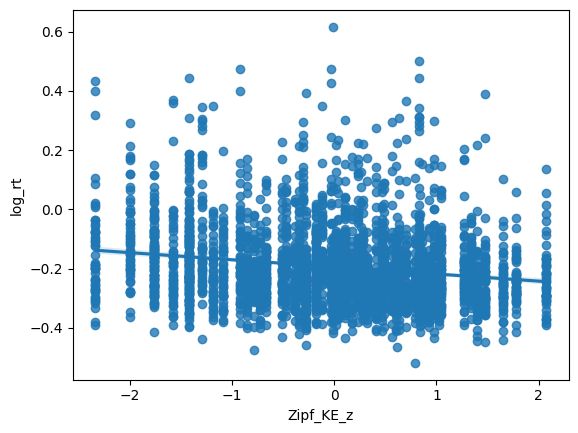

In [128]:
sns.regplot(x='Zipf_KE_z', y='log_rt', data=SUBTLEX_cumulative_df)

In [108]:
# LMM
formula = 'log_rt ~ Zipf_SUBTLEX*LexTALE' # regression formula
vc_formula = { # variance component formula
    "word": "0 + C(Stimuli)"
    }
re_formula = '~1' # random slope formula
#'~C(vowel_label)' 는 수렴하지 않아서 제외.
model = MixedLM.from_formula(formula,
    data=SUBTLEX_cumulative_df, 
    groups='Participant',
    vc_formula=vc_formula,
    re_formula=re_formula
    ).fit()
# groups에 id 
print("--- Statsmodels를 이용한 ANOVA 결과 ---")
model.summary()

--- Statsmodels를 이용한 ANOVA 결과 ---


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM   Dependent Variable:   log_rt   
No. Observations:     3060      Method:               REML     
No. Groups:           51        Scale:                0.0061   
Min. group size:      60        Log-Likelihood:       2113.5268
Max. group size:      60        Converged:            Yes      
Mean group size:      60.0                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.735    0.252  2.918 0.004  0.241  1.228
Zipf_SUBTLEX         -0.176    0.054 -3.272 0.001 -0.282 -0.071
LexTALE              -0.009    0.004 -2.484 0.013 -0.017 -0.002
Zipf_SUBTLEX:LexTALE  0.002    0.001  2.029 0.042  0.000  0.003
Participant Var       0.003                                    
word Var              0.008                                    
===============================================================

"""

In [109]:
print(f"R²: {return_r2(model):.4f}")

R²: 0.8525


In [110]:
# LMM
formula = 'log_rt ~ Zipf_KE*LexTALE' # regression formula
vc_formula = { # variance component formula
    "word": "0 + C(Stimuli)"
    }
re_formula = '~1' # random slope formula
#'~C(vowel_label)' 는 수렴하지 않아서 제외.
model = MixedLM.from_formula(formula,
    data=KE_cumulative_df, 
    groups='Participant',
    vc_formula=vc_formula,
    re_formula=re_formula
    ).fit()
# groups에 id 
print("--- Statsmodels를 이용한 ANOVA 결과 ---")
model.summary()

--- Statsmodels를 이용한 ANOVA 결과 ---


<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
==========================================================
Model:             MixedLM  Dependent Variable:  log_rt   
No. Observations:  3060     Method:              REML     
No. Groups:        51       Scale:               0.0043   
Min. group size:   60       Log-Likelihood:      2659.5713
Max. group size:   60       Converged:           Yes      
Mean group size:   60.0                                   
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        0.338    0.284  1.189 0.235 -0.219  0.894
Zipf_KE         -0.091    0.050 -1.811 0.070 -0.190  0.008
LexTALE         -0.007    0.004 -1.681 0.093 -0.016  0.001
Zipf_KE:LexTALE  0.001    0.001  1.433 0.152 -0.000  0.003
Participant Var  0.002                                    
word Var         0.005                                    
==========================================================

"""

In [111]:
print(f"R²: {return_r2(model):.4f}")

R²: 0.8473


In [132]:
# LMM
formula = 'log_rt ~ Zipf_KE'
model = MixedLM.from_formula(formula, data=KE_cumulative_df, groups='Participant', #re_formula='~ C(Stimuli)'
    ).fit()
# groups에 id 
print("--- Statsmodels를 이용한 ANOVA 결과 ---")
#result = pd.DataFrame(model.summary().tables[1])
#result['reject'] = result['PR(>F)'] < 0.05
#result
model.summary()

--- Statsmodels를 이용한 ANOVA 결과 ---


<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
==========================================================
Model:             MixedLM  Dependent Variable:  log_rt   
No. Observations:  2340     Method:              REML     
No. Groups:        39       Scale:               0.0088   
Min. group size:   60       Log-Likelihood:      2154.7432
Max. group size:   60       Converged:           Yes      
Mean group size:   60.0                                   
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept       -0.171    0.044 -3.847 0.000 -0.258 -0.084
Zipf_KE         -0.014    0.008 -1.820 0.069 -0.030  0.001
Participant Var  0.003    0.007                           
==========================================================

"""

In [143]:
# LMM
formula = 'log_rt ~ Zipf_SUBTLEX'
model = MixedLM.from_formula(formula, data=KE_cumulative_df, groups='Participant', #re_formula='~ C(Stimuli)'
    ).fit()
# groups에 id 
print("--- Statsmodels를 이용한 ANOVA 결과 ---")
#result = pd.DataFrame(model.summary().tables[1])
#result['reject'] = result['PR(>F)'] < 0.05
#result
model.summary()

--- Statsmodels를 이용한 ANOVA 결과 ---


<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
===========================================================
Model:              MixedLM  Dependent Variable:  log_rt   
No. Observations:   2340     Method:              REML     
No. Groups:         39       Scale:               0.0088   
Min. group size:    60       Log-Likelihood:      2152.4279
Max. group size:    60       Converged:           Yes      
Mean group size:    60.0                                   
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept       -0.246    0.023 -10.672 0.000 -0.291 -0.201
Zipf_SUBTLEX    -0.001    0.004  -0.185 0.853 -0.009  0.007
Participant Var  0.003    0.007                            
===========================================================

"""

<Axes: xlabel='Zipf_KE', ylabel='log_rt'>

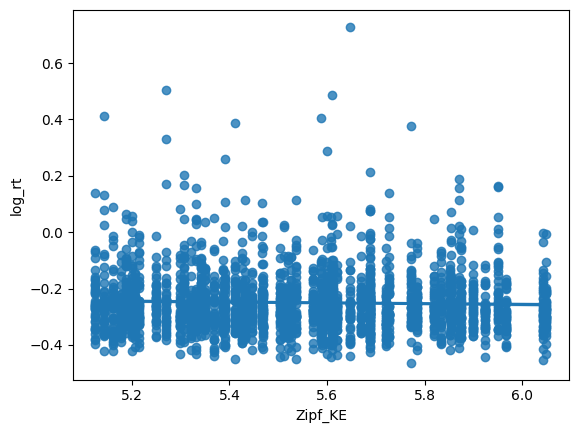

In [138]:
#plt.ylim(-0.6, 1)
sns.regplot(x='Zipf_KE', y='log_rt', data=KE_cumulative_df)

<Axes: xlabel='Zipf_SUBTLEX', ylabel='log_rt'>

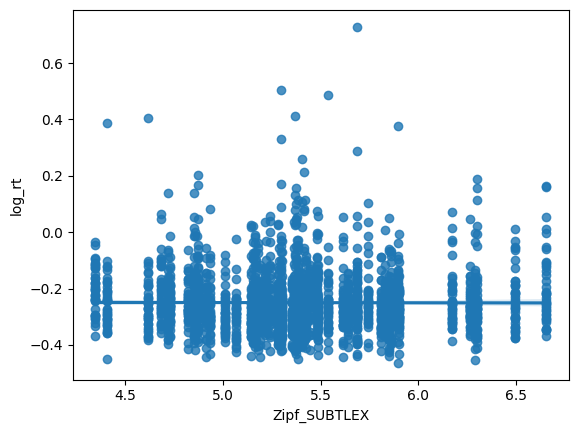

In [140]:
sns.regplot(x='Zipf_SUBTLEX', y='log_rt', data=KE_cumulative_df)

In [103]:
# LMM
formula = 'log_rt ~ LexTALE*Zipf_KE'
model = MixedLM.from_formula(formula, data=KE_cumulative_df, groups='Participant', #re_formula='~ C(Stimuli)'
    ).fit()
# groups에 id 
print("--- Statsmodels를 이용한 ANOVA 결과 ---")
#result = pd.DataFrame(model.summary().tables[1])
#result['reject'] = result['PR(>F)'] < 0.05
#result
model.summary()

--- Statsmodels를 이용한 ANOVA 결과 ---


<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
==========================================================
Model:             MixedLM  Dependent Variable:  log_rt   
No. Observations:  2340     Method:              REML     
No. Groups:        39       Scale:               0.0088   
Min. group size:   60       Log-Likelihood:      2140.6638
Max. group size:   60       Converged:           Yes      
Mean group size:   60.0                                   
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept       -0.168    0.063 -2.665 0.008 -0.291 -0.044
LexTALE         -0.001    0.001 -1.322 0.186 -0.003  0.001
Zipf_KE         -0.004    0.014 -0.276 0.783 -0.032  0.024
LexTALE:Zipf_KE  0.000    0.000  0.032 0.975 -0.000  0.000
Participant Var  0.003    0.007                           
==========================================================

"""

In [83]:
y_pred = model.fittedvalues
y_true = model.model.endog
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
print(f"R²: {r2:.4f}")

R²: 0.2430


In [84]:
# LMM
formula = 'log_rt ~ KE_rank'
model = MixedLM.from_formula(formula, data=KE_cumulative_df, groups='Participant', #re_formula='~ C(Stimuli)'
    ).fit()
# groups에 id 
print("--- Statsmodels를 이용한 ANOVA 결과 ---")
#result = pd.DataFrame(model.summary().tables[1])
#result['reject'] = result['PR(>F)'] < 0.05
#result
model.summary()

--- Statsmodels를 이용한 ANOVA 결과 ---


<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
===========================================================
Model:              MixedLM  Dependent Variable:  log_rt   
No. Observations:   2340     Method:              REML     
No. Groups:         39       Scale:               0.0088   
Min. group size:    60       Log-Likelihood:      2150.4688
Max. group size:    60       Converged:           Yes      
Mean group size:    60.0                                   
-----------------------------------------------------------
                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept       -0.260    0.010 -25.548 0.000 -0.280 -0.240
KE_rank          0.000    0.000   1.815 0.070 -0.000  0.000
Participant Var  0.003    0.007                            
===========================================================

"""

In [85]:
y_pred = model.fittedvalues
y_true = model.model.endog
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
print(f"R²: {r2:.4f}")

R²: 0.2430


In [86]:
# LMM
formula = 'log_rt ~ KE_rank * Zipf_KE'
model = MixedLM.from_formula(formula, data=KE_cumulative_df, groups='Participant', #re_formula='~ C(Stimuli)'
    ).fit()
# groups에 id 
print("--- Statsmodels를 이용한 ANOVA 결과 ---")
#result = pd.DataFrame(model.summary().tables[1])
#result['reject'] = result['PR(>F)'] < 0.05
#result
model.summary()

--- Statsmodels를 이용한 ANOVA 결과 ---


<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
==========================================================
Model:             MixedLM  Dependent Variable:  log_rt   
No. Observations:  2340     Method:              REML     
No. Groups:        39       Scale:               0.0088   
Min. group size:   60       Log-Likelihood:      2143.3779
Max. group size:   60       Converged:           Yes      
Mean group size:   60.0                                   
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        0.188    0.564  0.334 0.739 -0.917  1.293
KE_rank          0.004    0.003  1.287 0.198 -0.002  0.009
Zipf_KE         -0.067    0.089 -0.759 0.448 -0.241  0.106
KE_rank:Zipf_KE -0.001    0.001 -1.388 0.165 -0.002  0.000
Participant Var  0.003    0.007                           
==========================================================

"""

In [87]:
y_pred = model.fittedvalues
y_true = model.model.endog
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
print(f"R²: {r2:.4f}")

R²: 0.2437
